In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from nltk.sentiment import SentimentIntensityAnalyzer

In [11]:
df = pd.read_csv("Dataset/Reviews.csv")

# Take only the first 10,000 reviews
df = df.head(10000)

df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [3]:
sia = SentimentIntensityAnalyzer()

In [4]:
def get_sentiment(text):
    score = sia.polarity_scores(str(text))

    if score["compound"] >= 0.05:
        return "Positive"
    elif score["compound"] <= -0.05:
        return "Negative"
    else:
        return "Neutral"

In [5]:
df["Sentiment"] = df["Text"].apply(get_sentiment)

In [6]:
df[["Text", "Sentiment"]].head(10)

,Text,Sentiment
0,I have bought several of the Vitality canned d...,Positive
1,Product arrived labeled as Jumbo Salted Peanut...,Negative
2,This is a confection that has been around a fe...,Positive
3,If you are looking for the secret ingredient i...,Neutral
4,Great taffy at a great price. There was a wid...,Positive
5,I got a wild hair for taffy and ordered this f...,Positive
6,This saltwater taffy had great flavors and was...,Positive
7,This taffy is so good. It is very soft and ch...,Positive
8,Right now I'm mostly just sprouting this so my...,Positive
9,This is a very healthy dog food. Good for thei...,Positive


In [7]:
# Count each sentiment
sentiment_counts = df["Sentiment"].value_counts()

print(sentiment_counts)

Sentiment
Positive    8743
Negative    1049
Neutral      208
Name: count, dtype: int64


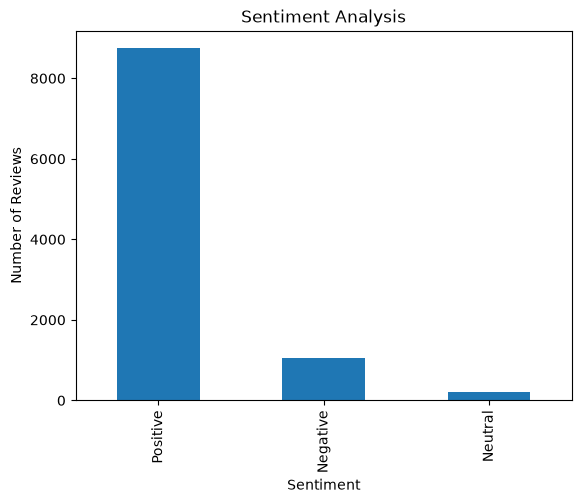

In [8]:
# Bar Chart
sentiment_counts.plot(kind="bar")

plt.title("Sentiment Analysis")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

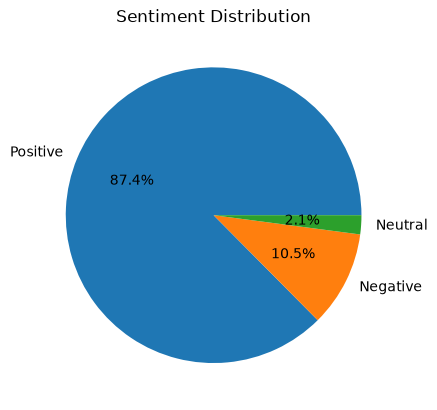

In [9]:
# Pie Chart
sentiment_counts.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Sentiment Distribution")
plt.ylabel("")

plt.show()

In [10]:
df.to_csv("sentiment_results.csv", index=False)

print("Results saved successfully!")

Results saved successfully!
